# UAH-DriveSet: Data Loading, Preprocessing and Visualization
Run cell by cell. Take one screenshot (code + output) per cell.

In [3]:
# Cell 1: Imports and settings
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Change this path according to the location of the dataset on your computer.
DATA_DIR = r"C:\Users\ASUS\Desktop\SRM KTR\B-tech_computer_science\semester-5\MLT\Driver-Behavior-and-Driving-Risk-Recognition\UAH-DRIVESET-v1\UAH-DRIVESET-v1"

WINDOW = 20      # samples per window (~2 s at ~10 Hz)
STEP = 10        # step between windows (50% overlap)
PLOT_DIR = "../plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Column layouts from the UAH-DriveSet README. If head() looks wrong, edit these.
ACC_COLS = ["t", "active", "ax", "ay", "az", "ax_kf", "ay_kf", "az_kf",
            "roll", "pitch", "yaw"]
GPS_COLS = ["t", "speed", "lat", "lon", "alt", "vacc", "hacc", "course", "difcourse"]
EVENT_TYPES = {1: "Braking", 2: "Turning", 3: "Acceleration"}
LABEL_NAMES = {0: "Normal", 1: "Braking", 2: "Turning", 3: "Acceleration"}

sns.set_theme(style="whitegrid")
print("DATA_DIR exists:", os.path.isdir(DATA_DIR))

DATA_DIR exists: True


In [4]:
# Cell 2: Load all trips (DATA UPLOADING)
def read_txt(path, names):
    """Read a whitespace-separated dataset file. Returns None if missing/empty."""
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return None
    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python",
                     on_bad_lines="skip")
    df = df.iloc[:, :len(names)]
    df.columns = names[:df.shape[1]]
    return df


def load_trips(data_dir):
    trips = []
    pattern = re.compile(r"-(D\d)-(NORMAL|AGGRESSIVE|DROWSY)\d*-(MOTORWAY|SECONDARY)",
                         re.IGNORECASE)
    for d in sorted(glob.glob(os.path.join(data_dir, "D[1-6]"))):
        for trip_dir in sorted(glob.glob(os.path.join(d, "*"))):
            if not os.path.isdir(trip_dir):
                continue
            name = os.path.basename(trip_dir)
            m = pattern.search(name)
            if not m:
                continue
            acc = read_txt(os.path.join(trip_dir, "RAW_ACCELEROMETERS.txt"), ACC_COLS)
            gps = read_txt(os.path.join(trip_dir, "RAW_GPS.txt"), GPS_COLS)
            ev = read_txt(os.path.join(trip_dir, "EVENTS_INERTIAL.txt"),
                          ["t", "type", "level"])
            if acc is None or gps is None:
                continue
            trips.append({"name": name, "driver": m.group(1).upper(),
                          "behavior": m.group(2).upper(), "road": m.group(3).upper(),
                          "acc": acc, "gps": gps, "events": ev})
    return trips


trips = load_trips(DATA_DIR)
print(f"Loaded {len(trips)} trips")

meta = pd.DataFrame([{k: t[k] for k in ("name", "driver", "behavior", "road")}
                     for t in trips])
print("\nTrips per driver and behavior:")
print(pd.crosstab(meta["driver"], meta["behavior"]))

print("\nAccelerometer (first trip):")
print(trips[0]["acc"].head())
print("\nGPS (first trip):")
print(trips[0]["gps"].head())
print("\nInertial events (first trip):")
print(trips[0]["events"].head() if trips[0]["events"] is not None else "no events")

Loaded 40 trips

Trips per driver and behavior:
behavior  AGGRESSIVE  DROWSY  NORMAL
driver                              
D1                 2       2       3
D2                 2       2       3
D3                 2       2       3
D4                 2       2       3
D5                 2       2       3
D6                 1       2       2

Accelerometer (first trip):
      t  active     ax     ay     az  ax_kf  ay_kf  az_kf   roll  pitch    yaw
0  6.94       1  0.017 -0.011  0.018 -0.005  0.008  0.018 -1.523  0.015  0.012
1  7.03       1  0.046  0.007  0.019  0.016 -0.002  0.018 -1.522  0.012  0.012
2  7.14       1  0.052 -0.016  0.027  0.037 -0.005  0.018 -1.520  0.014  0.011
3  7.24       1  0.015 -0.016  0.026  0.038 -0.009  0.024 -1.523  0.014  0.011
4  7.34       1 -0.014 -0.017  0.040  0.012 -0.016  0.032 -1.525  0.012  0.011

GPS (first trip):
       t  speed        lat       lon    alt  vacc  hacc  course  difcourse
0   7.85   65.2  40.512787 -3.404477  612.7     4     5   3

In [6]:
# Cell 3: Missing values and summary statistics (PREPROCESSING)
all_acc = pd.concat([t["acc"] for t in trips], ignore_index=True)
all_gps = pd.concat([t["gps"] for t in trips], ignore_index=True)

print("Missing values - accelerometer:\n", all_acc.isna().sum())
print("\nMissing values - GPS:\n", all_gps[["t", "speed"]].isna().sum())
print("\nAccelerometer summary statistics:")
print(all_acc[["ax_kf", "ay_kf", "az_kf", "roll", "pitch", "yaw"]].describe().round(3))
print("\nGPS speed summary (km/h):")
print(all_gps["speed"].describe().round(2))

dt = np.median(np.diff(trips[0]["acc"]["t"].values))
print(f"\nSampling interval (accelerometer): {dt:.3f} s  (~{1/dt:.1f} Hz)")
print(f"Window of {WINDOW} samples = {WINDOW*dt:.1f} s")

Missing values - accelerometer:
 t         0
active    0
ax        0
ay        0
az        0
ax_kf     0
ay_kf     0
az_kf     0
roll      0
pitch     0
yaw       0
dtype: int64

Missing values - GPS:
 t        0
speed    0
dtype: int64

Accelerometer summary statistics:
            ax_kf       ay_kf       az_kf        roll       pitch         yaw
count  311385.000  311385.000  311385.000  311385.000  311385.000  311385.000
mean       -0.013      -0.009      -0.004      -1.557      -0.012      -0.074
std         0.027       0.067       0.029       0.038       0.073       1.592
min        -0.263      -0.615      -0.572      -1.896      -0.461      -3.141
25%        -0.026      -0.015      -0.015      -1.578      -0.026      -1.019
50%        -0.012       0.000      -0.002      -1.556      -0.004      -0.039
75%         0.002       0.014       0.010      -1.534       0.016       0.794
max         0.270       0.352       0.186      -1.219       0.352       3.141

GPS speed summary (km/h):

In [7]:
# Cell 4: Cleaning, merging speed, sliding windows, features, labels
SIGNALS = ["ax_kf", "ay_kf", "az_kf", "roll", "pitch", "yaw", "speed"]


def clean_trip(t):
    acc = t["acc"].drop_duplicates(subset="t").sort_values("t").reset_index(drop=True)
    gps = t["gps"].drop_duplicates(subset="t").sort_values("t").reset_index(drop=True)
    acc = acc.interpolate(limit_direction="both")
    df = pd.merge_asof(acc, gps[["t", "speed"]], on="t", direction="nearest")
    df["speed"] = df["speed"].fillna(0)
    return df


def window_label(ev, t0, t1):
    """Label = type of the highest-level event inside the window, else 0 (Normal)."""
    if ev is None or len(ev) == 0:
        return 0
    inside = ev[(ev["t"] >= t0) & (ev["t"] <= t1)]
    if len(inside) == 0:
        return 0
    row = inside.sort_values("level", ascending=False).iloc[0]
    typ = int(row["type"])
    return typ if typ in EVENT_TYPES else 0


def build_features(trips):
    rows = []
    for t in trips:
        df = clean_trip(t)
        arr = df[SIGNALS].values
        tt = df["t"].values
        n = len(df)
        for s in range(0, n - WINDOW + 1, STEP):
            w = arr[s:s + WINDOW]
            feats = {}
            for j, sig in enumerate(SIGNALS):
                x = w[:, j]
                feats[f"{sig}_mean"] = x.mean()
                feats[f"{sig}_std"] = x.std()
                feats[f"{sig}_min"] = x.min()
                feats[f"{sig}_max"] = x.max()
            feats["acc_xy_mag_std"] = np.sqrt(w[:, 0] ** 2 + w[:, 1] ** 2).std()
            lab = window_label(t["events"], tt[s], tt[s + WINDOW - 1])
            rows.append({"trip": t["name"], "driver": t["driver"],
                         "behavior": t["behavior"], "road": t["road"],
                         "label": lab, "label_name": LABEL_NAMES[lab], **feats})
    return pd.DataFrame(rows)


features = build_features(trips)
FEATURE_COLS = [c for c in features.columns
                if c not in ("trip", "driver", "behavior", "road", "label", "label_name")]
features.to_csv("../uah_features.csv", index=False)

print("Feature table shape:", features.shape)
print("Number of features:", len(FEATURE_COLS))
print("\nWindow label counts:")
print(features["label_name"].value_counts())
print("\nWindow label percentages:")
print((features["label_name"].value_counts(normalize=True) * 100).round(2))
print(features.head())

# Normalization demo (z-score). The training script applies this inside its pipeline.
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform(features[FEATURE_COLS])
print("\nAfter z-score normalization: mean ~", scaled.mean().round(3),
      ", std ~", scaled.std().round(3))

Feature table shape: (31055, 35)
Number of features: 29

Window label counts:
label_name
Normal          29860
Braking           520
Turning           366
Acceleration      309
Name: count, dtype: int64

Window label percentages:
label_name
Normal          96.15
Braking          1.67
Turning          1.18
Acceleration     1.00
Name: proportion, dtype: float64
                                       trip driver behavior       road  label  \
0  20151110175712-16km-D1-NORMAL1-SECONDARY     D1   NORMAL  SECONDARY      0   
1  20151110175712-16km-D1-NORMAL1-SECONDARY     D1   NORMAL  SECONDARY      0   
2  20151110175712-16km-D1-NORMAL1-SECONDARY     D1   NORMAL  SECONDARY      0   
3  20151110175712-16km-D1-NORMAL1-SECONDARY     D1   NORMAL  SECONDARY      0   
4  20151110175712-16km-D1-NORMAL1-SECONDARY     D1   NORMAL  SECONDARY      0   

  label_name  ax_kf_mean  ax_kf_std  ax_kf_min  ax_kf_max  ...  pitch_max  \
0     Normal     0.00190   0.017082     -0.030      0.038  ...      0.029 

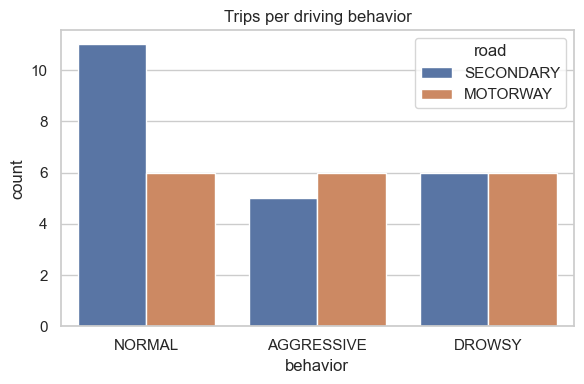

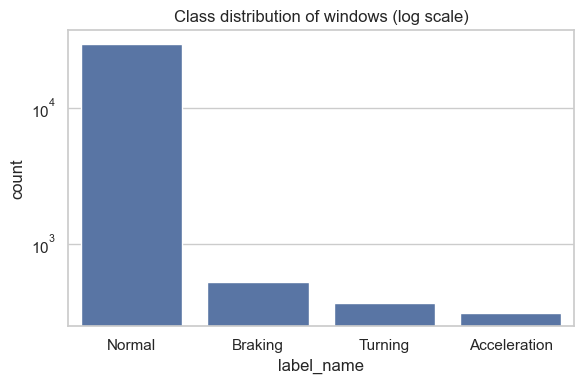

In [8]:
# Cell 5: Trips per behavior and class imbalance (VISUALIZATION)
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=meta, x="behavior", hue="road", ax=ax)
ax.set_title("Trips per driving behavior")
plt.tight_layout(); plt.savefig(f"{PLOT_DIR}/01_trips_per_behavior.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
order = [LABEL_NAMES[i] for i in range(4)]
sns.countplot(data=features, x="label_name", order=order, ax=ax)
ax.set_yscale("log")
ax.set_title("Class distribution of windows (log scale)")
plt.tight_layout(); plt.savefig(f"{PLOT_DIR}/02_class_imbalance.png", dpi=150); plt.show()

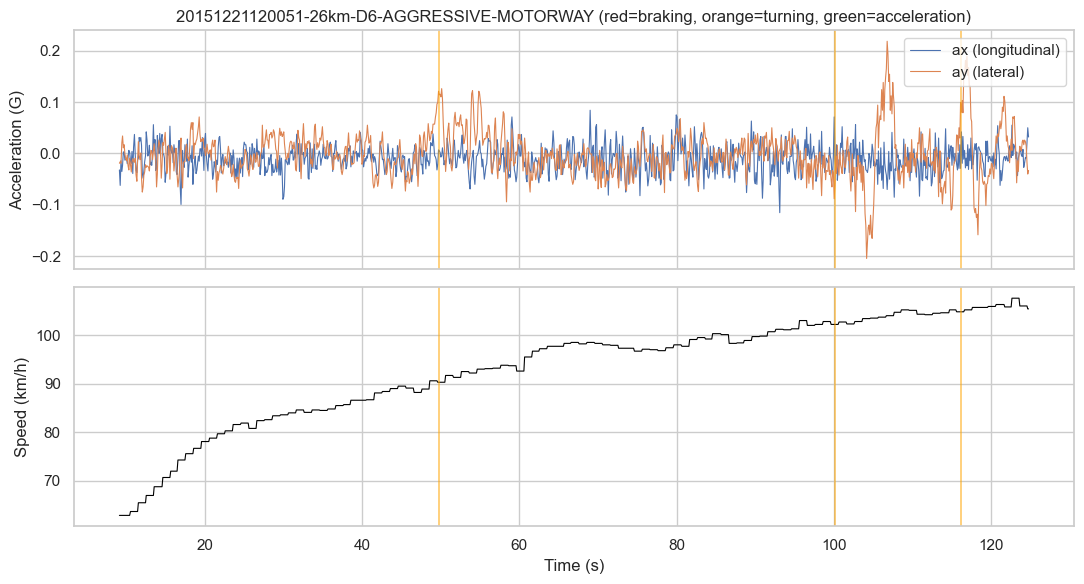

Selected trip: 20151221120051-26km-D6-AGGRESSIVE-MOTORWAY
Number of events: 80
Displayed time: 9.17 to 124.78
Events displayed:
        t  type  level
0   49.78     2      1
1  100.06     2      1
2  116.08     2      1


In [9]:
# Cell 6: Signals with events marked

# Pick an aggressive trip with the largest number of events
candidates = [
    t for t in trips
    if t["behavior"] == "AGGRESSIVE"
    and t["events"] is not None
    and len(t["events"]) > 0
]

pick = max(candidates, key=lambda t: len(t["events"]))

df = clean_trip(pick)

# Get event times that fall within the trip
event_times = pick["events"]["t"].astype(float).values

# Choose the first event as the center of the displayed segment
center = event_times[0]

# Display 150 seconds around that event
start = max(df["t"].min(), center - 75)
end = min(df["t"].max(), center + 75)

seg = df[(df["t"] >= start) & (df["t"] <= end)]

# Event colors
colors = {
    1: "red",       # braking
    2: "orange",    # turning
    3: "green"      # acceleration
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 6),
    sharex=True
)

# Acceleration signals
axes[0].plot(
    seg["t"],
    seg["ax_kf"],
    label="ax (longitudinal)",
    lw=0.8
)

axes[0].plot(
    seg["t"],
    seg["ay_kf"],
    label="ay (lateral)",
    lw=0.8
)

axes[0].set_ylabel("Acceleration (G)")
axes[0].legend(loc="upper right")

# Speed
axes[1].plot(
    seg["t"],
    seg["speed"],
    color="black",
    lw=0.8
)

axes[1].set_ylabel("Speed (km/h)")
axes[1].set_xlabel("Time (s)")

# Mark events that occur inside the displayed section
for _, e in pick["events"].iterrows():

    event_time = float(e["t"])

    if start <= event_time <= end:

        event_type = int(e["type"])

        for ax in axes:
            ax.axvline(
                event_time,
                color=colors.get(event_type, "gray"),
                alpha=0.6,
                lw=1.2
            )

axes[0].set_title(
    f"{pick['name']} "
    "(red=braking, orange=turning, green=acceleration)"
)

plt.tight_layout()

plt.savefig(
    f"{PLOT_DIR}/03_signals_with_events.png",
    dpi=150
)

plt.show()

print("Selected trip:", pick["name"])
print("Number of events:", len(pick["events"]))
print("Displayed time:", round(start, 2), "to", round(end, 2))
print("Events displayed:")
print(
    pick["events"][
        (pick["events"]["t"] >= start) &
        (pick["events"]["t"] <= end)
    ]
)

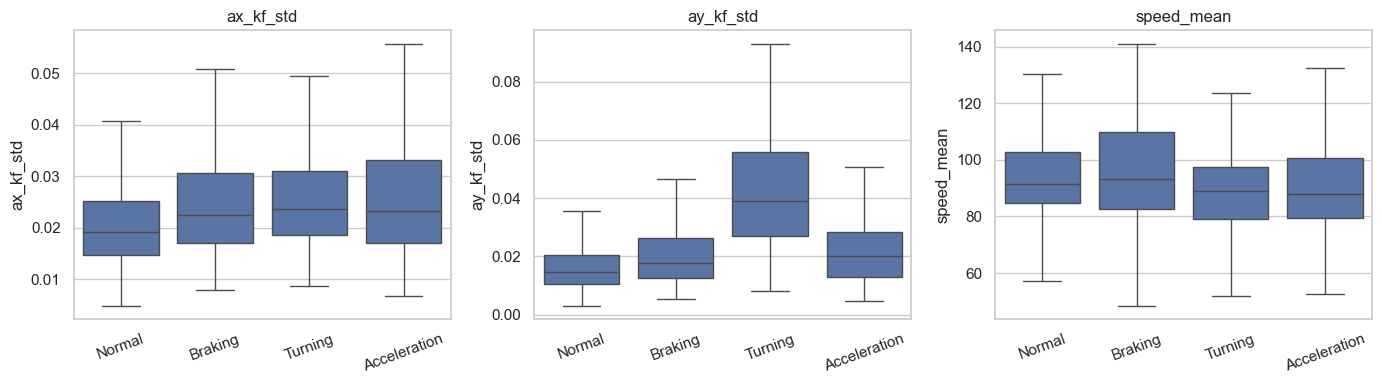

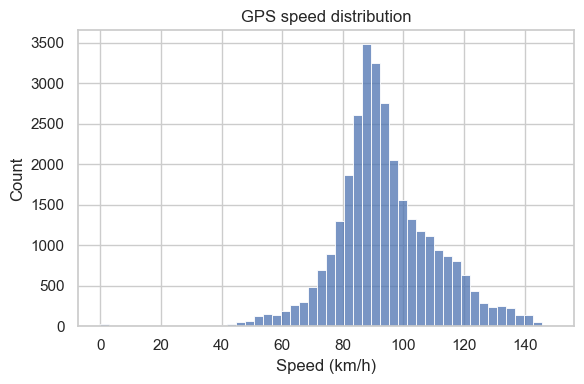

In [10]:
# Cell 7: Feature boxplots and speed histogram
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for a, col in zip(axes, ["ax_kf_std", "ay_kf_std", "speed_mean"]):
    sns.boxplot(data=features, x="label_name", y=col, order=order, ax=a,
                showfliers=False)
    a.set_title(col); a.set_xlabel("")
    a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(f"{PLOT_DIR}/04_feature_boxplots.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(all_gps["speed"], bins=50, ax=ax)
ax.set_title("GPS speed distribution"); ax.set_xlabel("Speed (km/h)")
plt.tight_layout(); plt.savefig(f"{PLOT_DIR}/05_speed_histogram.png", dpi=150); plt.show()

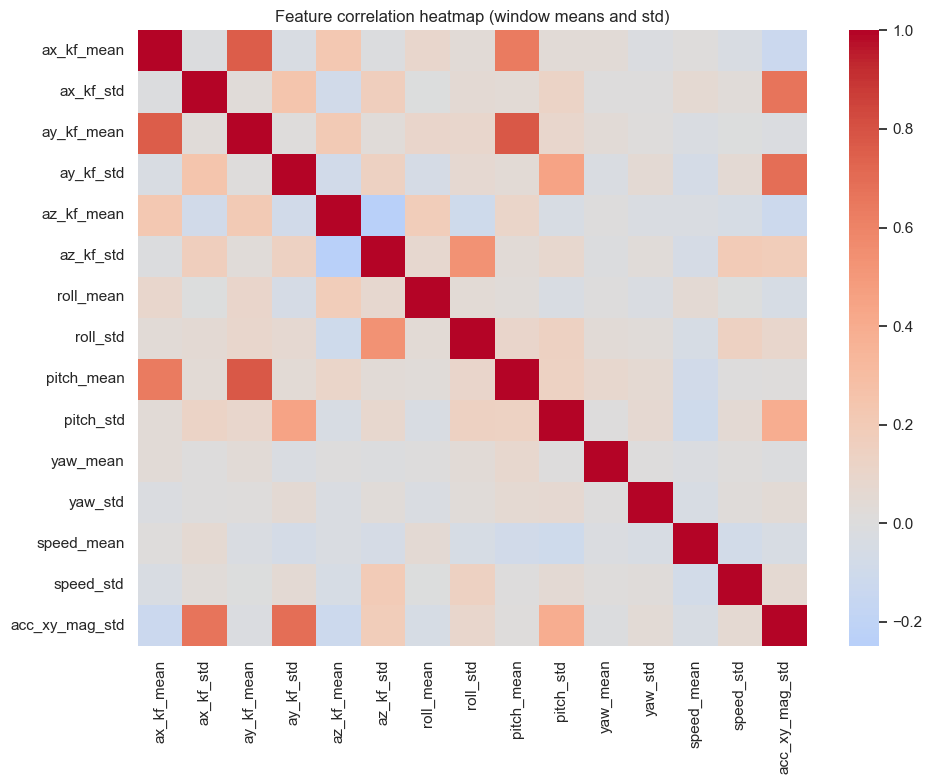

In [11]:
# Cell 8: Correlation heatmap
corr_cols = [c for c in FEATURE_COLS if c.endswith("_mean") or c.endswith("_std")]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(features[corr_cols].corr(), cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation heatmap (window means and std)")
plt.tight_layout(); plt.savefig(f"{PLOT_DIR}/06_correlation_heatmap.png", dpi=150); plt.show()

event       Acceleration  Braking  Turning
behavior                                  
AGGRESSIVE           110      183       72
DROWSY                36       61       79
NORMAL                29       34       48


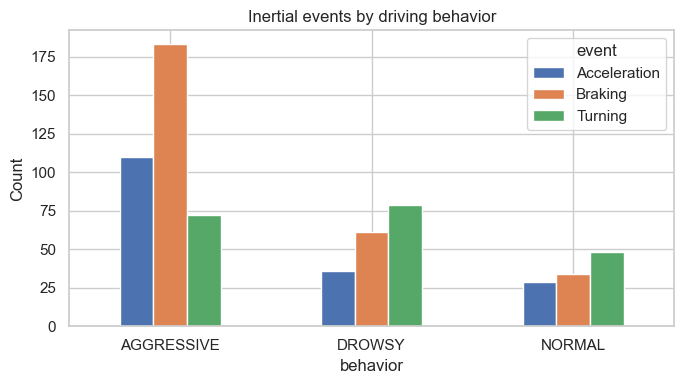


Done. Saved uah_features.csv and plots in: c:\Users\ASUS\Desktop\SRM KTR\B-tech_computer_science\semester-5\MLT\Driver-Behavior-and-Driving-Risk-Recognition\plots


In [12]:
# Cell 9: Events by driving behavior
ev_rows = []
for t in trips:
    if t["events"] is not None:
        e = t["events"].copy()
        e["behavior"] = t["behavior"]
        ev_rows.append(e)
if ev_rows:
    ev_all = pd.concat(ev_rows, ignore_index=True)
    ev_all["event"] = ev_all["type"].map(EVENT_TYPES)
    counts = ev_all.groupby(["behavior", "event"]).size().unstack(fill_value=0)
    print(counts)
    counts.plot(kind="bar", figsize=(7, 4))
    plt.title("Inertial events by driving behavior"); plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout(); plt.savefig(f"{PLOT_DIR}/07_events_by_behavior.png", dpi=150); plt.show()

print("\nDone. Saved uah_features.csv and plots in:", os.path.abspath(PLOT_DIR))

In [2]:
import os
print(os.getcwd())

c:\Users\ASUS\Desktop\SRM KTR\B-tech_computer_science\semester-5\MLT\Driver-Behavior-and-Driving-Risk-Recognition\notebooks
